# SECTION 1. SETUP AND INSTALLATIONS


In [1]:
#IMPORTS
import pandas as pd
import numpy as np
import os
import re
import nltk
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# SECTION 2. DATA LOADING AND EXPLORATION

In [2]:
import kagglehub

path = kagglehub.dataset_download("gowrishankarp/newspaper-text-summarization-cnn-dailymail")
inner_path = os.path.join(path, "cnn_dailymail")
print(os.listdir(inner_path))

df = pd.read_csv(os.path.join(inner_path, "train.csv"))
df = df[['article', 'highlights']].dropna()
df = df.sample(5000, random_state=42).reset_index(drop=True)

print(f"Shape: {df.shape}")
df.head(3)

100%|██████████| 503M/503M [00:13<00:00, 38.8MB/s] 

Extracting files...


['train.csv', 'test.csv', 'validation.csv']
Shape: (5000, 2)


,article,highlights
0,By . Mia De Graaf . Britons flocked to beaches...,People enjoyed temperatures of 17C at Brighton...
1,A couple who weighed a combined 32st were sham...,Couple started piling on pounds after the birt...
2,Video footage shows the heart stopping moment ...,A 17-year-old boy suffering lacerations to his...


### EDA - DATA EXPLORATION

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample Article:\n", df['article'][0][:300])
print("\nSample Highlight:\n", df['highlights'][0])

df['article_len'] = df['article'].apply(lambda x: len(x.split()))
df['highlight_len'] = df['highlights'].apply(lambda x: len(x.split()))

print("\nArticle Length Statistics:")
print(df['article_len'].describe())
print("\nHighlight Length Statistics:")
print(df['highlight_len'].describe())

Shape: (5000, 2)

Columns: ['article', 'highlights']

Sample Article:
 By . Mia De Graaf . Britons flocked to beaches across the southern coast yesterday as millions look set to bask in glorious sunshine today. Temperatures soared to 17C in Brighton and Dorset, with people starting their long weekend in deck chairs by the sea. Figures from Asda suggest the unexpected s

Sample Highlight:
 People enjoyed temperatures of 17C at Brighton beach in West Sussex and Weymouth in Dorset .
Asda claims it will sell a million sausages over long weekend despite night temperatures dropping to minus 1C .
But the good weather has not been enjoyed by all as the north west and Scotland have seen heavy rain .

Article Length Statistics:
count    5000.000000
mean      698.094600
std       343.526824
min        21.000000
25%       447.750000
50%       636.000000
75%       885.000000
max      1955.000000
Name: article_len, dtype: float64

Highlight Length Statistics:
count    5000.000000
mean       51.89960

# SECTION 3. DATA PREPROCESSING AND CLEANING

In [4]:
def clean_text(text):
    text = text.lower()
    # CNN/DailyMail articles often start with "(CNN)" as a dateline tag
    text = re.sub(r'\(cnn\)', '', text)
    # Replace em dashes with space e.g. war--peace -> war peace
    text = re.sub(r'--', ' ', text)
    # Expand contractions
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"n\'t", " not", text)
    # Remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['article_clean'] = df['article'].apply(clean_text)

# Add <sos> and <eos> tokens to highlights
df['highlights_clean'] = df['highlights'].apply(
    lambda x: '<sos> ' + clean_text(x) + ' <eos>'
)

df[['article_clean', 'highlights_clean']].head(3)

,article_clean,highlights_clean
0,by mia de graaf britons flocked to beaches acr...,<sos> people enjoyed temperatures of 17c at br...
1,a couple who weighed a combined 32st were sham...,<sos> couple started piling on pounds after th...
2,video footage shows the heart stopping moment ...,<sos> a 17yearold boy suffering lacerations to...


### TOKENIZATION AND PADDING

In [5]:
MAX_ARTICLE_LEN = 400
MAX_HIGHLIGHT_LEN = 50
VOCAB_SIZE = 20000

# Articles tokenize
art_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
art_tokenizer.fit_on_texts(df['article_clean'])
art_sequences = art_tokenizer.texts_to_sequences(df['article_clean'])
art_padded = pad_sequences(art_sequences, maxlen=MAX_ARTICLE_LEN, padding='post', truncating='post')

# Highlights tokenize
hl_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
hl_tokenizer.fit_on_texts(df['highlights_clean'])
hl_sequences = hl_tokenizer.texts_to_sequences(df['highlights_clean'])
hl_padded = pad_sequences(hl_sequences, maxlen=MAX_HIGHLIGHT_LEN, padding='post', truncating='post')

print("Article shape:", art_padded.shape)
print("Highlight shape:", hl_padded.shape)
print("Article vocab size:", len(art_tokenizer.word_index))
print("Highlight vocab size:", len(hl_tokenizer.word_index))

Article shape: (5000, 400)
Highlight shape: (5000, 50)
Article vocab size: 83502
Highlight vocab size: 26268


### Train/Val/Test Split

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    art_padded, hl_padded, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (4000, 400)
Val:   (500, 400)
Test:  (500, 400)


# SECTION 4. Seq2Seq BiLSTM WITH BAHDANAU ATTENTION

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Embedding, Dense,
                                      Bidirectional, Concatenate, 
                                      RepeatVector, Layer, Dropout)

class BahdanauAttention(Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V  = Dense(1)

    def call(self, inputs):
        encoder_output, decoder_hidden = inputs
        decoder_hidden = tf.expand_dims(decoder_hidden, 1)
        score = self.V(tf.nn.tanh(self.W1(encoder_output) + self.W2(decoder_hidden)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * encoder_output
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector

# ── Encoder ──
encoder_inputs = Input(shape=(MAX_ARTICLE_LEN,))
enc_emb = Embedding(VOCAB_SIZE, 128, trainable=True)(encoder_inputs)
enc_emb = Dropout(0.3)(enc_emb)
encoder_bilstm = Bidirectional(LSTM(256, return_sequences=True, 
                                     return_state=True, dropout=0.3))
encoder_out, fwd_h, fwd_c, bwd_h, bwd_c = encoder_bilstm(enc_emb)
state_h = Concatenate()([fwd_h, bwd_h])
state_c = Concatenate()([fwd_c, bwd_c])

# ── Decoder ──
decoder_inputs = Input(shape=(MAX_HIGHLIGHT_LEN,))
dec_emb = Embedding(VOCAB_SIZE, 128, trainable=True)(decoder_inputs)
dec_emb = Dropout(0.3)(dec_emb)
decoder_out, _, _ = LSTM(512, return_sequences=True, 
                          return_state=True, dropout=0.3)(
    dec_emb, initial_state=[state_h, state_c])

# ── Attention ──
context_vector = BahdanauAttention(units=256)([encoder_out, state_h])
context_vector = RepeatVector(MAX_HIGHLIGHT_LEN)(context_vector)

# ── Combine + Output ──
decoder_combined = Concatenate()([decoder_out, context_vector])
decoder_combined = Dropout(0.3)(decoder_combined)
output = Dense(VOCAB_SIZE, activation='softmax')(decoder_combined)

# ── Compile ──
model = Model([encoder_inputs, decoder_inputs], output)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 400, 128)  │  2,560,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 400, 128)  │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ [(None, 400,      │    788,480 │ dropout[0][0]     │
│ (Bidirectional)     │ 512), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 50, 128)   │  2,560,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 512)       │          0 │ bidirectional_1[… │
│ (Concatenate)       │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50, 128)   │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 512)       │          0 │ bidirectional_1[… │
│ (Concatenate)       │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention… │ (None, 512)       │    262,913 │ bidirectional_1[… │
│ (BahdanauAttention) │                   │            │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 50, 512), │  1,312,768 │ dropout_1[0][0],  │
│                     │ (None, 512),      │            │ concatenate_3[0]… │
│                     │ (None, 512)]      │            │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 50, 512)   │          0 │ bahdanau_attenti… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 50, 1024)  │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 50, 1024)  │          0 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 50, 20000) │ 20,500,000 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,984,161 (106.75 MB)

 Trainable params: 27,984,161 (106.75 MB)

 Non-trainable params: 0 (0.00 B)

### MODEL TRAINING

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

# Pad to correct length
from tensorflow.keras.preprocessing.sequence import pad_sequences

decoder_input_data  = pad_sequences(y_train[:, :-1], maxlen=MAX_HIGHLIGHT_LEN, padding='post')
decoder_target_data = pad_sequences(y_train[:, 1:],  maxlen=MAX_HIGHLIGHT_LEN, padding='post')

decoder_input_val  = pad_sequences(y_val[:, :-1], maxlen=MAX_HIGHLIGHT_LEN, padding='post')
decoder_target_val = pad_sequences(y_val[:, 1:],  maxlen=MAX_HIGHLIGHT_LEN, padding='post')

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    [X_train, decoder_input_data],
    decoder_target_data,
    validation_data=([X_val, decoder_input_val], decoder_target_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

print("Training complete!")

Epoch 1/30


63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 366ms/step - accuracy: 0.1644 - loss: 7.1222 - val_accuracy: 0.1814 - val_loss: 6.4885
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 363ms/step - accuracy: 0.1886 - loss: 6.3195 - val_accuracy: 0.1854 - val_loss: 6.4277
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 367ms/step - accuracy: 0.1967 - loss: 6.2066 - val_accuracy: 0.1994 - val_loss: 6.3827
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 395ms/step - accuracy: 0.2044 - loss: 6.0934 - val_accuracy: 0.2031 - val_loss: 6.3484
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 384ms/step - accuracy: 0.2075 - loss: 5.9897 - val_accuracy: 0.2043 - val_loss: 6.3355
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 394ms/step - accuracy: 0.2104 - loss: 5.8896 - val_accuracy: 0.2067 - val_loss: 6.3344
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 391ms/step - accuracy: 0.2125 - loss: 5.7962 - val_accuracy: 0.2083 - val_loss: 6.3433
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 388ms/step - accuracy: 0.2141 - loss: 5.6922 - val_accuracy: 0.209

In [16]:
model.save('/content/drive/MyDrive/headline_generation_lstm.keras')
print("Model saved!")

Model saved!


### PLOT MODEL

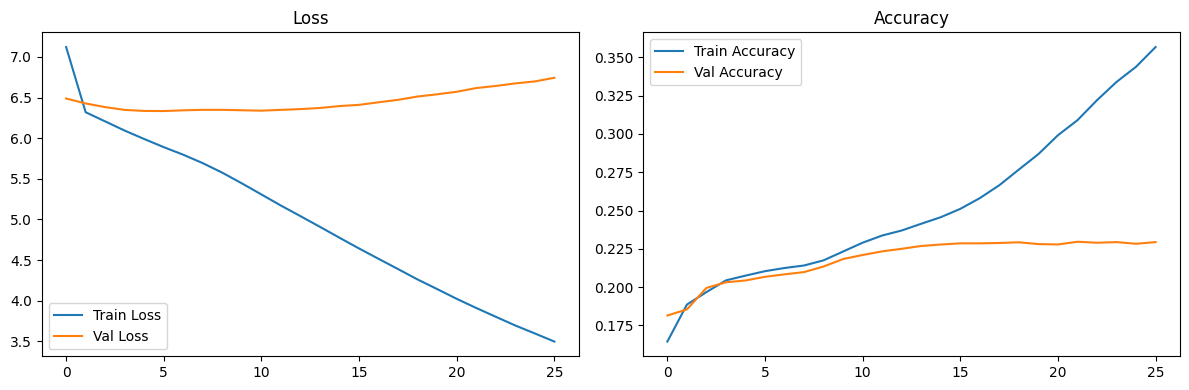

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
import os
os.makedirs('/content/drive/MyDrive/NLP_Project', exist_ok=True)

model.save('/content/drive/MyDrive/NLP_Project/headline_generation_lstm.keras')
print("Saved!")

Saved!
